In [1]:
!pip install torch torchvision
!pip install torchmetrics
!pip install pytorch_msssim

In [2]:
import os
import cv2
import numpy as np

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torchvision.transforms as transforms

from pytorch_msssim import ssim

from tqdm import tqdm

In [3]:
TRAIN_DIR = "dataset_split/train"
VAL_DIR = "dataset_split/val"
TEST_DIR = "dataset_split/test"

IMAGE_SIZE = 256

BATCH_SIZE = 8

EPOCHS = 50

LEARNING_RATE = 1e-4

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [4]:
class RestorationDataset(Dataset):

    def __init__(self, root_dir):

        self.clean_dir = os.path.join(
            root_dir,
            "clean"
        )

        self.damaged_dir = os.path.join(
            root_dir,
            "damaged"
        )

        self.files = sorted(
            os.listdir(
                self.clean_dir
            )
        )

        self.transform = transforms.Compose([
            transforms.Resize(
                (IMAGE_SIZE, IMAGE_SIZE)
            ),
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        clean = Image.open(
            os.path.join(
                self.clean_dir,
                filename
            )
        ).convert("RGB")

        damaged = Image.open(
            os.path.join(
                self.damaged_dir,
                filename
            )
        ).convert("RGB")

        clean = self.transform(clean)

        damaged = self.transform(damaged)

        return damaged, clean

In [5]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

In [21]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)

        # Bottleneck
        self.bottleneck = DoubleConv(
            256,
            512
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            512,
            256
        )

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv2d(
            32,
            3,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        output = self.final(d1)

        return torch.sigmoid(output)

In [22]:
class CombinedLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.l1 = nn.L1Loss()

    def forward(
        self,
        pred,
        target
    ):

        l1_loss = self.l1(
            pred,
            target
        )

        ssim_loss = (
            1 -
            ssim(
                pred,
                target,
                data_range=1,
                size_average=True
            )
        )

        return (
            0.8 * l1_loss
            +
            0.2 * ssim_loss
        )

In [23]:
train_dataset = RestorationDataset(
    TRAIN_DIR
)

val_dataset = RestorationDataset(
    VAL_DIR
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [24]:
model = UNet().to(
    DEVICE
)

criterion = CombinedLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [25]:
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    for damaged, clean in tqdm(
        train_loader
    ):

        damaged = damaged.to(
            DEVICE
        )

        clean = clean.to(
            DEVICE
        )

        optimizer.zero_grad()

        output = model(
            damaged
        )

        loss = criterion(
            output,
            clean
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(
        train_loader
    )

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for damaged, clean in val_loader:

            damaged = damaged.to(
                DEVICE
            )

            clean = clean.to(
                DEVICE
            )

            output = model(
                damaged
            )

            loss = criterion(
                output,
                clean
            )

            val_loss += loss.item()

    val_loss /= len(
        val_loader
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train={train_loss:.4f} "
        f"Val={val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_unet.pth"
        )

        print(
            "Best model saved."
        )

100%|██████████| 275/275 [02:59<00:00,  1.53it/s]


Epoch [1/50] Train=0.1905 Val=0.1475
Best model saved.


100%|██████████| 275/275 [02:56<00:00,  1.56it/s]


Epoch [2/50] Train=0.1413 Val=0.1305
Best model saved.


100%|██████████| 275/275 [02:56<00:00,  1.56it/s]


...

Epoch [48/50] Train=0.0884 Val=0.1028
Best model saved.


100%|██████████| 275/275 [02:57<00:00,  1.55it/s]


Epoch [49/50] Train=0.0882 Val=0.1059


100%|██████████| 275/275 [02:57<00:00,  1.55it/s]


Epoch [50/50] Train=0.0883 Val=0.1071


In [26]:
model.load_state_dict(
    torch.load(
        "best_unet.pth",
        map_location=DEVICE
    )
)

model.eval()

UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc

In [27]:
def restore_image(path):

    image = Image.open(
        path
    ).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize(
            (256,256)
        ),
        transforms.ToTensor()
    ])

    x = transform(image)

    x = x.unsqueeze(0).to(
        DEVICE
    )

    with torch.no_grad():

        y = model(x)

    y = y.squeeze(0)

    y = y.cpu().permute(
        1,2,0
    ).numpy()

    return y

In [28]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

def restore_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor()
    ])

    x = transform(image)

    x = x.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        output = model(x)

    output = output.squeeze(0)

    output = output.cpu().permute(
        1,2,0
    ).numpy()

    return np.clip(output,0,1)

In [95]:
test_dataset = RestorationDataset(
    TEST_DIR
)

damaged, clean = test_dataset[1]

print(damaged.shape)
print(clean.shape)

torch.Size([3, 256, 256])
torch.Size([3, 256, 256])


In [96]:
model.eval()

with torch.no_grad():

    output = model(
        damaged.unsqueeze(0).to(DEVICE)
    )

pred = output.squeeze().cpu()

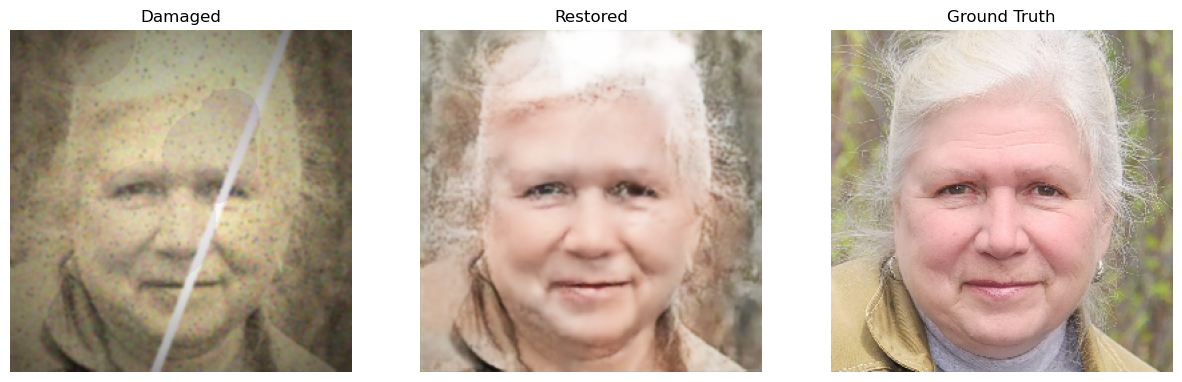

In [97]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

ax[0].imshow(
    damaged.permute(1,2,0)
)
ax[0].set_title("Damaged")
ax[0].axis("off")

ax[1].imshow(
    pred.permute(1,2,0)
)
ax[1].set_title("Restored")
ax[1].axis("off")

ax[2].imshow(
    clean.permute(1,2,0)
)
ax[2].set_title("Ground Truth")
ax[2].axis("off")

plt.show()

In [46]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [47]:
import torch
import torch.nn.functional as F

def calculate_psnr(pred, target):

    mse = F.mse_loss(
        pred,
        target
    )

    psnr = (
        20 *
        torch.log10(
            torch.tensor(1.0)
        )
        -
        10 *
        torch.log10(mse)
    )

    return psnr.item()

In [48]:
psnr_scores = []

model.eval()

with torch.no_grad():

    for damaged, clean in test_loader:

        damaged = damaged.to(DEVICE)

        clean = clean.to(DEVICE)

        pred = model(damaged)

        psnr_scores.append(
            calculate_psnr(
                pred,
                clean
            )
        )

print(
    "Average PSNR:",
    np.mean(psnr_scores)
)

Average PSNR: 20.768423533035538


In [50]:
from pytorch_msssim import ssim

ssim_scores = []

model.eval()

with torch.no_grad():

    for damaged, clean in test_loader:

        damaged = damaged.to(DEVICE)

        clean = clean.to(DEVICE)

        pred = model(damaged)

        score = ssim(
            pred,
            clean,
            data_range=1,
            size_average=True
        )

        ssim_scores.append(
            score.item()
        )

print(
    "Average SSIM:",
    np.mean(ssim_scores)
)

Average SSIM: 0.7548923987453267


In [52]:
output = pred[0]

output = (
    output.cpu()
    .permute(1,2,0)
    .numpy()
    * 255
).astype(np.uint8)

Image.fromarray(output).save(
    "restored.jpg"
)

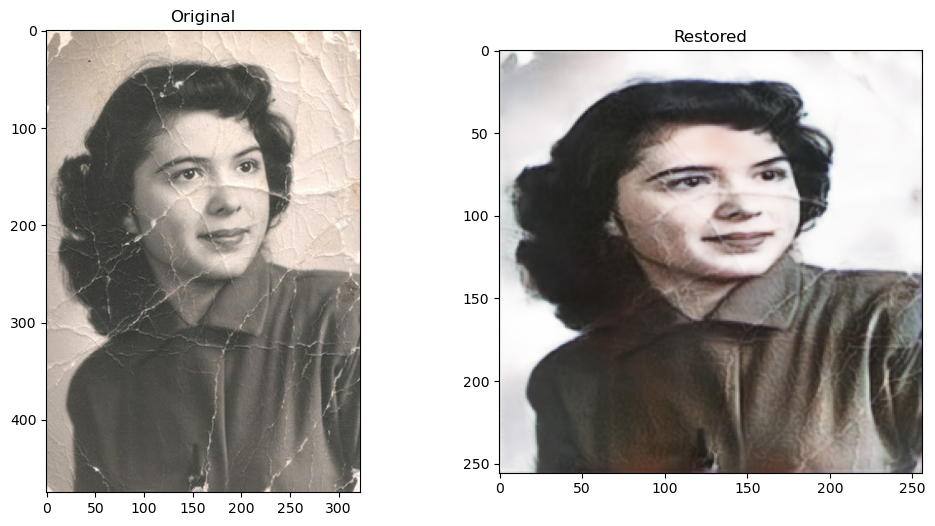

In [58]:
restored = restore_image(
    "input3.jpg"
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(Image.open("input3.jpg"))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(restored)
plt.title("Restored")

plt.show()